In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv("Feature_engineering_done.csv")
df.drop(columns=['Unnamed: 0'] , axis=0 , inplace=True)

In [4]:
df

,latitude,longitude,road_lighting,number_of_lanes,speed_limit_kmph,estimated_speed_kmph,traffic_signal_present,median_present,visibility_km,temperature_c,...,primary_cause_Overspeeding,primary_cause_Pedestrian Error,primary_cause_Poor Road Condition,primary_cause_Poor Visibility,primary_cause_Signal Violation,primary_cause_Weather,primary_cause_Wrong-Side Driving,helmet_seatbelt_used_No,helmet_seatbelt_used_Not Applicable,helmet_seatbelt_used_Yes
0,15.741067,74.555047,0,6.0,60.0,80.8,1,1,3.76,9.0,...,0,0,0,0,1,0,0,0,0,1
1,23.782972,86.281103,0,3.0,60.0,76.4,1,0,3.16,28.8,...,0,0,1,0,0,0,0,1,0,0
2,24.872909,87.339504,0,1.0,60.0,65.9,0,1,9.61,12.8,...,0,0,0,0,1,0,0,1,0,0
3,24.305082,74.252979,1,2.0,60.0,75.3,1,0,3.24,18.4,...,0,0,0,0,0,0,0,0,1,0
4,21.053234,71.671556,1,2.0,40.0,64.5,0,0,5.23,30.3,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154551,28.856258,76.939912,1,4.0,60.0,61.3,1,1,9.79,22.3,...,0,0,0,0,0,0,0,0,0,1
154552,16.247233,80.497432,1,1.0,60.0,46.6,0,1,0.79,14.0,...,0,0,0,0,0,0,0,0,0,1
154553,29.577508,82.371175,1,3.0,60.0,41.1,0,1,8.38,22.7,...,0,0,0,0,0,0,1,0,0,1
154554,27.544344,82.830455,1,2.0,40.0,28.5,0,1,0.49,25.3,...,0,1,0,0,0,0,0,0,1,0


## It is a Classification problem in which we predict the Severity of accident
- Minor : 0
- Moderate : 1
- Severe : 2
- Fatal : 3

In [5]:
X = df.drop(columns=['accident_severity'] , axis=0)
y = df['accident_severity']

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA

- In PCA we have to find a unit vector for which there is maximum Variance on that vector so for that we apply linear transformation on each vector using Covariance matrix and find Eigen Vector of covariance matrix

- Linear transformation : with the help of matrix we can transform any vector changed it direction and magnitude called Linear transformation

- Eigen Vector : Eigen Vector are the vector whose Direction are not changed after performing linear transformation 
For each Matrix there is unique eigen vector


- Eigen value : For every eigen vector there is eigen value which tell how much time the magnitude of Eigen Vector change 


- we find the eigen vector of covariance matrix and find the largest eigen vector(whose eigen value is largest) 
that eigen vector is meant to be a unit vector which we needed and give maximum variance (spread)

In [7]:
from sklearn.decomposition import PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [8]:
X_pca.shape

(154556, 101)

In [9]:
pca.components_

array([[ 3.45994952e-03, -1.46801733e-03, -5.29100094e-02, ...,
         7.24614670e-02, -2.06215179e-01,  1.32011704e-01],
       [ 3.72304682e-03, -2.20951015e-03, -2.32184336e-02, ...,
        -1.87979879e-01,  5.53525923e-01, -3.60134110e-01],
       [-7.50864848e-03, -3.48518130e-03, -4.18050545e-03, ...,
         2.04890736e-03,  4.99321318e-03, -6.57073818e-03],
       ...,
       [-3.87041774e-21, -1.48304428e-17, -7.30698505e-17, ...,
         3.37614813e-02,  7.05554072e-03,  3.80559051e-02],
       [ 0.00000000e+00,  9.85716115e-17,  1.11570716e-16, ...,
         1.56754339e-02,  4.83794909e-03,  1.76693322e-02],
       [-0.00000000e+00,  4.58772359e-17,  1.30265931e-16, ...,
        -8.02499504e-03, -1.26032415e-02, -9.04576571e-03]],
      shape=(101, 101))

In [10]:
pca.explained_variance_ratio_

array([2.82926563e-02, 2.78577128e-02, 2.03007357e-02, 1.98248543e-02,
       1.97104743e-02, 1.96186842e-02, 1.95521847e-02, 1.82347411e-02,
       1.74976429e-02, 1.74791104e-02, 1.73057534e-02, 1.63903313e-02,
       1.61425219e-02, 1.56252345e-02, 1.46878808e-02, 1.43948245e-02,
       1.41716503e-02, 1.36745608e-02, 1.35445017e-02, 1.28409900e-02,
       1.24461848e-02, 1.18662659e-02, 1.16319734e-02, 1.15518497e-02,
       1.12938983e-02, 1.12454403e-02, 1.11987581e-02, 1.11526248e-02,
       1.10950940e-02, 1.10234126e-02, 1.09438871e-02, 1.08089905e-02,
       1.07745594e-02, 1.07587284e-02, 1.06621347e-02, 1.06214500e-02,
       1.05910321e-02, 1.05604656e-02, 1.05201499e-02, 1.04902549e-02,
       1.04697518e-02, 1.04520108e-02, 1.04472434e-02, 1.04226837e-02,
       1.03868731e-02, 1.03425724e-02, 1.03001038e-02, 1.02697557e-02,
       1.02528504e-02, 1.02330565e-02, 1.02125802e-02, 1.02084001e-02,
       1.01780129e-02, 1.01666911e-02, 1.01427567e-02, 1.00822427e-02,
      

In [11]:
np.cumsum(pca.explained_variance_ratio_)

array([0.02829266, 0.05615037, 0.0764511 , 0.09627596, 0.11598643,
       0.13560512, 0.1551573 , 0.17339204, 0.19088969, 0.2083688 ,
       0.22567455, 0.24206488, 0.2582074 , 0.27383264, 0.28852052,
       0.30291534, 0.31708699, 0.33076155, 0.34430606, 0.35714705,
       0.36959323, 0.3814595 , 0.39309147, 0.40464332, 0.41593722,
       0.42718266, 0.43838142, 0.44953404, 0.46062914, 0.47165255,
       0.48259643, 0.49340543, 0.50417998, 0.51493871, 0.52560085,
       0.5362223 , 0.54681333, 0.5573738 , 0.56789395, 0.5783842 ,
       0.58885395, 0.59930596, 0.60975321, 0.62017589, 0.63056276,
       0.64090534, 0.65120544, 0.6614752 , 0.67172805, 0.6819611 ,
       0.69217368, 0.70238208, 0.7125601 , 0.72272679, 0.73286954,
       0.74295179, 0.75302764, 0.76309191, 0.77313978, 0.78317762,
       0.79320977, 0.8032136 , 0.8131678 , 0.82308782, 0.83298894,
       0.84285977, 0.85272054, 0.86255817, 0.87238572, 0.88215683,
       0.89190443, 0.901605  , 0.91122319, 0.92062946, 0.92935

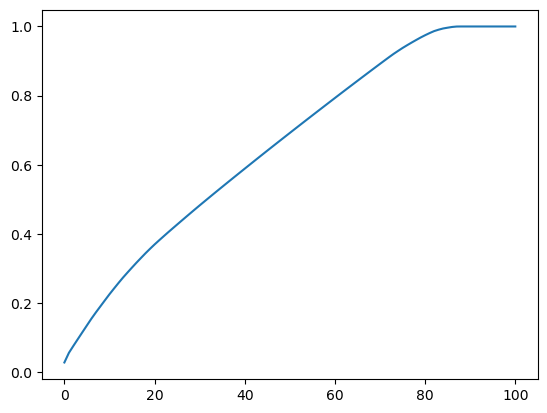

In [12]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
# plt.xlim(0,100)
# plt.ylim(0.4,1)

For pca we have to decide the no of component which cover 90% of variance from the data , So i decided to take 70 component in pca

In [13]:
pca = PCA(n_components=70)
X_pca = pca.fit_transform(X_scaled)

In [14]:
X_pca.shape

(154556, 70)

# Train-Test split

In [15]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X_pca, y , test_size=0.3,random_state=42)

# BAGGING(Random Forest)

In [ ]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import GridSearchCV

# RandomForest = RandomForestClassifier(n_jobs=-1)

# param = {
#     'n_estimators': [100, 200, 300 ,400 , 500],
#     'max_samples': [0.3,0.4,0.5,0.6],
#     'bootstrap': [True, False]
# }

# grid_search = GridSearchCV(
#     estimator=RandomForest,
#     param_grid=param,
#     cv=5,
# )

# grid_search.fit(X_train, y_train)

# print("Best Parameters:", grid_search.best_params_)
# # print("Best CV Score:", grid_search.best_score_)

In [17]:
from sklearn.ensemble import RandomForestClassifier

RandomForest = RandomForestClassifier(
    n_estimators=300,
    max_samples=0.4,
    bootstrap=True,
    random_state=42,
    n_jobs=-1,

)

RandomForest.fit(X_train, y_train)
y_pred = RandomForest.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score , f1_score , confusion_matrix , classification_report

accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
# recall = recall_score(y_test, y_pred)
# f1 = f1_score(y_test, y_pred)

print("Accurcy:", accuracy)
print("confusion:\n", confusion)
# print("recall:", recall)
# print("f1:", f1)
print(classification_report(y_test, y_pred))

Accurcy: 0.6914400327819354
confusion:
 [[22980  2301    20     0]
 [ 7448  6108   509     0]
 [  364  2298  2180   312]
 [    2   159   894   792]]
              precision    recall  f1-score   support

           0       0.75      0.91      0.82     25301
           1       0.56      0.43      0.49     14065
           2       0.61      0.42      0.50      5154
           3       0.72      0.43      0.54      1847

    accuracy                           0.69     46367
   macro avg       0.66      0.55      0.59     46367
weighted avg       0.67      0.69      0.67     46367



- Random Forest is enseemble technique majorly based on Bagging 
- In random forest 'n' no of decission tree train parallel on some percent of samples rows & columns from the data
- and for classification it use voting method and for regression mean is taken
- major differnce beteween Bagging and random forest is that is randomforest do node level sampling and bagging do tree level sampling

# ADABOOST 

In [19]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=50,
    random_state=42,
    learning_rate=0.1
)


ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)

In [20]:
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
print("Accurcy:", accuracy)
print("confusion:\n", confusion)
print(classification_report(y_test, y_pred))

Accurcy: 0.6155671059158453
confusion:
 [[23952  1209   140     0]
 [10418  2646  1001     0]
 [ 1439  1771  1944     0]
 [   78   348  1421     0]]
              precision    recall  f1-score   support

           0       0.67      0.95      0.78     25301
           1       0.44      0.19      0.26     14065
           2       0.43      0.38      0.40      5154
           3       0.00      0.00      0.00      1847

    accuracy                           0.62     46367
   macro avg       0.39      0.38      0.36     46367
weighted avg       0.55      0.62      0.55     46367



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


- Adaboost is enseemble technique majorly based on boosting
- In Boosting multiple model train to make final prediction it is also called aditive method
- Fistly it provide equal weight to each column and then predict its first result
- Based on first prediction it updates its weight if prediction is correct than weight decrease and if prediction is wrong than weight increase
- more weight rows cover more range than less weight rows so after random row sampling for next model chances of comming wrong predicticed rows is high
- Final prediction is done by formula 
y = a1p1 + a2p2 + a3p3 + ......... + anpn
where , a is called alpha depend on wrong prediction
and p is a model



# XGBOOST

In [36]:
import xgboost as xgb

xg = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    # max_depth=3,
    random_state=42
)

xg.fit(X_train, y_train)
y_pred = xg.predict(X_test)

In [38]:
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
print("Accurcy:", accuracy)
print("confusion:\n", confusion)
print(classification_report(y_test, y_pred))

Accurcy: 0.702633338365648
confusion:
 [[22228  3025    48     0]
 [ 6373  6756   925    11]
 [  209  1874  2561   510]
 [    1    93   719  1034]]
              precision    recall  f1-score   support

           0       0.77      0.88      0.82     25301
           1       0.58      0.48      0.52     14065
           2       0.60      0.50      0.54      5154
           3       0.66      0.56      0.61      1847

    accuracy                           0.70     46367
   macro avg       0.65      0.60      0.62     46367
weighted avg       0.69      0.70      0.69     46367



- XGBOOST is a library based on gradient boosting
- Its full name is Extreme Gradient boosting 
- Differene beteween Gradient boosting and XGBOOST are : 
- - XGBOOST is more faster model for big data due to its use optimize data structure algorithm to store data
- - In XGBOOST it check similarity to split the data
- - Xgboost can train the model on both CPU as well as GPU

## From the above 3 model maximum accuracy is obtain by XGBOOST so i Import XGboost model for deployment

In [40]:
import joblib, json

ordinal_cols = ['alcohol_involved','median_present','traffic_signal_present',
                'hospitalization_required','police_called','ambulance_called',
                'emergency_services_called','fatigue_involved','mobile_phone_used',
                'distraction_involved','road_lighting','vehicle_condition']
ohe_col = ['state','road_condition','road_type','area_type','license_status',
           'driver_gender','weather_condition','junction_type','vehicle_type',
           'primary_cause','helmet_seatbelt_used']

numeric_cols = [c for c in X.columns
                if c not in ordinal_cols
                and not any(c.startswith(o + "_") for o in ohe_col)]

numeric = {c: {"min": float(X[c].min()), "max": float(X[c].max()),
               "median": float(X[c].median()),
               "is_int": bool((X[c] == X[c].round()).all())}
           for c in numeric_cols}

json.dump({"feature_columns": list(X.columns), "numeric": numeric},
          open("MOdels/meta.json", "w"))

joblib.dump(scaler, "MOdels/scaler.joblib")
joblib.dump(pca, "MOdels/pca.joblib")
joblib.dump(xg, "MOdels/model.joblib", compress=3)

['MOdels/model.joblib']

In [42]:
import sklearn, xgboost
print(sklearn.__version__, xgboost.__version__)

1.7.2 3.4.1
